# **Overfitting `vs.` Underfitting**

## 1. Setup and Baseline Model

In [1]:
%%time
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping

# ignore warnings in the output
import warnings
warnings.filterwarnings("ignore")

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Define a simple model
def create_model():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = create_model()

# Train the baseline model
history_baseline = model.fit(x_train, y_train, epochs=10, validation_split=0.2, verbose=1)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7968 - loss: 7.9904 - val_accuracy: 0.8863 - val_loss: 0.5618
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9000 - loss: 0.4251 - val_accuracy: 0.9125 - val_loss: 0.3692
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9260 - loss: 0.2920 - val_accuracy: 0.9307 - val_loss: 0.2822
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9409 - loss: 0.2285 - val_accuracy: 0.9338 - val_loss: 0.2997
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9435 - loss: 0.2154 - val_accuracy: 0.9439 - val_loss: 0.2676
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9481 - loss: 0.2055 - val_accuracy: 0.9351 - val_loss: 0.3131
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9519 - loss: 0.1918 - val_accuracy: 0.9440 - val_loss: 0.2874
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9561 - loss: 0.1775 

we have created simple baseline model and trained it for 10 epochs. Before any preprocessingand also saved the each epoch accuracy and loss separtely


## 2. Run model on Normalized Data

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8647 - loss: 0.4878 - val_accuracy: 0.9518 - val_loss: 0.1626
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9594 - loss: 0.1407 - val_accuracy: 0.9672 - val_loss: 0.1136
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9737 - loss: 0.0859 - val_accuracy: 0.9699 - val_loss: 0.1004
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9812 - loss: 0.0624 - val_accuracy: 0.9688 - val_loss: 0.1057
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9851 - loss: 0.0498 - val_accuracy: 0.9738 - val_loss: 0.0822
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9883 - loss: 0.0383 - val_accuracy: 0.9752 - val_loss: 0.0837
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9912 - loss: 0.0295 - val_accuracy: 0.9693 - val_loss: 0.1045
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9938 - loss: 0.0231 - 

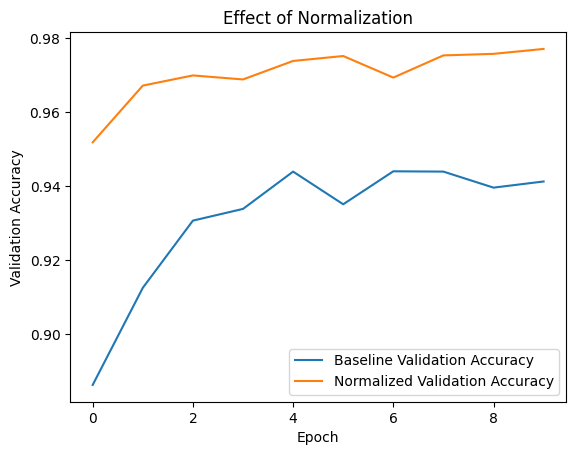

CPU times: total: 1min 25s
Wall time: 1min 12s


In [ ]:
%%time   # This command measures the execution time
# laod and normalize the data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0    # normalize the data because the pixel values are in the range of 0-255, and we want them to be in the range of 0-1 for better training performance.

# Define a model for normalized data
def create_model_with_norm_data():
    model = Sequential([                                # sequential creates a linear stack of layers, layers are connected with each other after another
        Flatten(input_shape=(28, 28)),                  # flatten converts each image into a 1D array of 28*28=784 pixels, input_shape specifies the shape of the input data
        Dense(128, activation='relu'),   # we used relu  (creates hidden layers) because it is a non-linear activation function that allows the model to learn complex patterns in the data, and it is computationally efficient.
        Dense(10, activation='softmax')       # this is a
    ])
    
    # configures the model for training, specifying the optimizer, loss function, and metrics to monitor during training.
    model.compile(optimizer='adam',              # adam optimizer automatically adjusts the learning rate during training, which can lead to faster convergence and better performance.
                  loss='sparse_categorical_crossentropy',   # sparse_categorical_crossentropy is used for multi-class classification problems where the target labels are integers (not one-hot encoded).
                  metrics=['accuracy'])
    return model

model_with_norm_data = create_model_with_norm_data()

# Train the baseline model
history_norm_data = model_with_norm_data.fit(x_train, y_train, epochs=10, validation_split=0.2, verbose=1)

# plot the effect of normalization
plt.plot(history_baseline.history['val_accuracy'], label='Baseline Validation Accuracy')
plt.plot(history_norm_data.history['val_accuracy'], label = 'Normalized Validation Accuracy')
plt.title('Effect of Normalization')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

now after normalizing the data we can see that the validation accuracy is higher than the baseline model

## 3. Adding Dropout
Now, let's modify the model to include dropout and observe its effect.

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7963 - loss: 0.6622 - val_accuracy: 0.9488 - val_loss: 0.1824
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9245 - loss: 0.2517 - val_accuracy: 0.9588 - val_loss: 0.1361
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9406 - loss: 0.2000 - val_accuracy: 0.9632 - val_loss: 0.1257
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9487 - loss: 0.1701 - val_accuracy: 0.9678 - val_loss: 0.1072
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9511 - loss: 0.1627 - val_accuracy: 0.9698 - val_loss: 0.1028
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9565 - loss: 0.1455 - val_accuracy: 0.9700 - val_loss: 0.1007
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9569 - loss: 0.1339 - val_accuracy: 0.9719 - val_loss: 0.1012
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9618 - loss: 0.1271

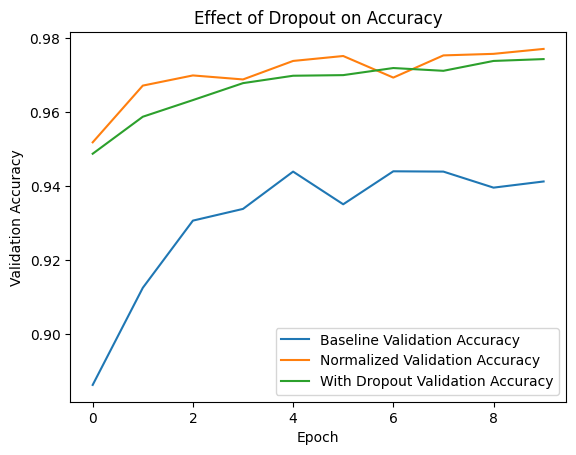

In [4]:
# Define a model with dropout
def create_model_with_dropout():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),  # Adding dropout layer to prevent overfitting by randomly setting 50% of the input units to 0 during training.
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_with_dropout = create_model_with_dropout()

# Train the model with dropout
history_dropout = model_with_dropout.fit(x_train, y_train, epochs=10, validation_split=0.2, verbose=1)   # verbose=1 means that the progress bar will be displayed

# Plotting the effect of dropout
plt.plot(history_baseline.history['val_accuracy'], label='Baseline Validation Accuracy')
# plot line for normalized data
plt.plot(history_norm_data.history['val_accuracy'], label='Normalized Validation Accuracy')
plt.plot(history_dropout.history['val_accuracy'], label='With Dropout Validation Accuracy')
plt.title('Effect of Dropout on Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()


## 4. Early Stopping
Finally, we will use early stopping to stop training when the validation loss starts to increase.

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8616 - loss: 0.4801 - val_accuracy: 0.9555 - val_loss: 0.1571
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9592 - loss: 0.1375 - val_accuracy: 0.9642 - val_loss: 0.1199
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9732 - loss: 0.0892 - val_accuracy: 0.9712 - val_loss: 0.1028
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9812 - loss: 0.0625 - val_accuracy: 0.9712 - val_loss: 0.0939
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9865 - loss: 0.0457 - val_accuracy: 0.9753 - val_loss: 0.0859
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9893 - loss: 0.0359 - val_accuracy: 0.9749 - val_loss: 0.0873
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9924 - loss: 0.0283 - val_accuracy: 0.9740 - val_loss: 0.0964
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9943 - loss: 0.0233 - 

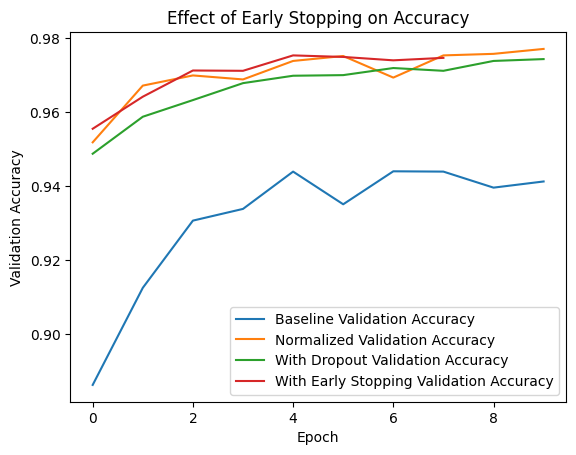

In [5]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3)

model_with_es = create_model_with_norm_data()

# train with early stop
history_es = model_with_es.fit(x_train, y_train, epochs=10, validation_split=0.2, verbose=1, callbacks=[early_stopping])

# plot the effect of early stopping
plt.plot(history_baseline.history['val_accuracy'], label='Baseline Validation Accuracy')
# plot line for normalized data
plt.plot(history_norm_data.history['val_accuracy'], label='Normalized Validation Accuracy')
plt.plot(history_dropout.history['val_accuracy'], label='With Dropout Validation Accuracy')
plt.plot(history_es.history['val_accuracy'], label='With Early Stopping Validation Accuracy')
plt.title('Effect of Early Stopping on Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

## 5. L1/L2 Regularization
L1 and L2 regularization are two common regularization techniques that can be used to reduce overfitting.

L1 in Keras: `kernel_regularizer=regularizers.l1(0.001)` 
L2 in Keras: `kernel_regularizer=regularizers.l2(0.001)`

L1 changes the loss function by adding the sum of the absolute weights to it. L2 changes the loss function by adding the sum of the squared weights to it. 
- `L1` make zero some of the weights. 
- `L2` make the weights small.

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7944 - loss: 0.9132 - val_accuracy: 0.9451 - val_loss: 0.3799
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9185 - loss: 0.4542 - val_accuracy: 0.9587 - val_loss: 0.3232
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9307 - loss: 0.4056 - val_accuracy: 0.9638 - val_loss: 0.2982
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9364 - loss: 0.3757 - val_accuracy: 0.9637 - val_loss: 0.2884
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9402 - loss: 0.3652 - val_accuracy: 0.9644 - val_loss: 0.2848
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9428 - loss: 0.3581 - val_accuracy: 0.9676 - val_loss: 0.2761
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9448 - loss: 0.3482 - val_accuracy: 0.9679 - val_loss: 0.2709
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9447 - loss: 0.3446 -

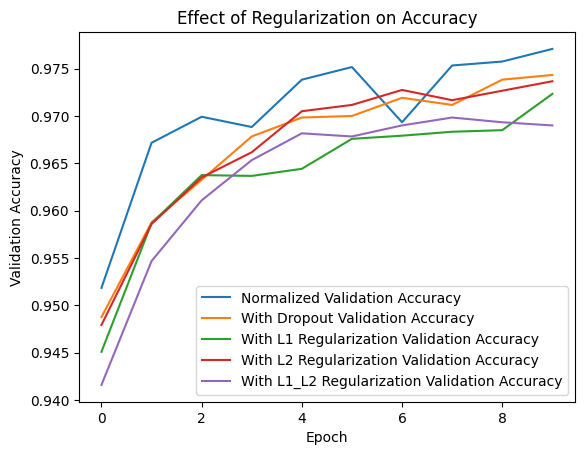

In [6]:
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l1, l2, l1_l2
import matplotlib.pyplot as plt

# Define a model with L1 regularization
def create_model_with_l1():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu', kernel_regularizer=l1(0.0001)),  # L1 regularization
        Dropout(0.5), # Adding dropout which will also be regularized by L1
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Define a model with L2 regularization
def create_model_with_l2():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu', kernel_regularizer=l2(0.0001)),  # L2 regularization
        Dropout(0.5), # Adding dropout which will also be regularized by L2
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# should we combine them both?
# Define a model with L1_L2 (combined) regularization
def create_model_with_l1_l2():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu', kernel_regularizer=l1_l2(l1=0.0001, l2=0.0001)),  # L1_L2 regularization
        Dropout(0.5), # Adding dropout which will also be regularized by L1_L2
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Prepare and train the models
model_with_l1 = create_model_with_l1()
history_l1 = model_with_l1.fit(x_train, y_train, epochs=10, validation_split=0.2, verbose=1)

model_with_l2 = create_model_with_l2()
history_l2 = model_with_l2.fit(x_train, y_train, epochs=10, validation_split=0.2, verbose=1)

model_with_l1_l2 = create_model_with_l1_l2()
history_l1_l2 = model_with_l1_l2.fit(x_train, y_train, epochs=10, validation_split=0.2, verbose=1)

# Plotting the effect of regularization
# plot line for normalized data
plt.plot(history_norm_data.history['val_accuracy'], label='Normalized Validation Accuracy')
plt.plot(history_dropout.history['val_accuracy'], label='With Dropout Validation Accuracy')
plt.plot(history_l1.history['val_accuracy'], label='With L1 Regularization Validation Accuracy')
plt.plot(history_l2.history['val_accuracy'], label='With L2 Regularization Validation Accuracy')
plt.plot(history_l1_l2.history['val_accuracy'], label='With L1_L2 Regularization Validation Accuracy')
plt.title('Effect of Regularization on Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

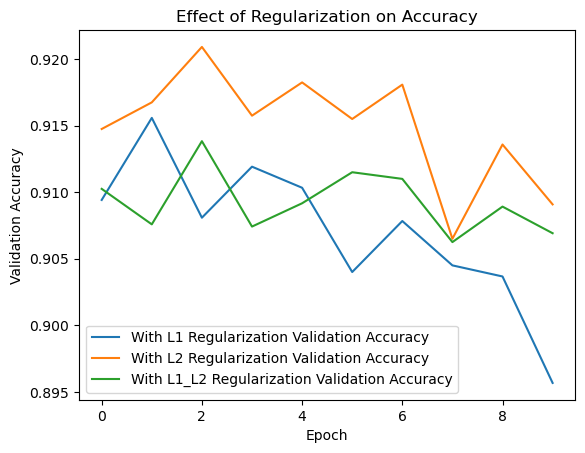

In [6]:
# Plotting the effect of regularization
# plot line for normalized data
# plt.plot(history_norm_data.history['val_accuracy'], label='Normalized Validation Accuracy')
# plt.plot(history_dropout.history['val_accuracy'], label='With Dropout Validation Accuracy')
plt.plot(history_l1.history['val_accuracy'], label='With L1 Regularization Validation Accuracy')
plt.plot(history_l2.history['val_accuracy'], label='With L2 Regularization Validation Accuracy')
plt.plot(history_l1_l2.history['val_accuracy'], label='With L1_L2 Regularization Validation Accuracy')
plt.title('Effect of Regularization on Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

## 6. K-fold cross validation

**`k-fold cross-validation in TensorFlow`** requires a bit more manual setup compared to libraries like scikit-learn, which offer built-in k-fold cross-validation functions. TensorFlow does not have a direct function for k-fold cross-validation, but you can achieve this by manually splitting your dataset into k folds and then training and evaluating your model on each fold.

Below is an example code that demonstrates how to perform k-fold cross-validation with the MNIST dataset in TensorFlow. This example uses a simple neural network similar to the ones discussed previously.

Epoch 1/10
  14/1500 [..............................] - ETA: 12s - loss: 1.9456 - accuracy: 0.3504

2024-02-12 14:38:50.014312: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1498/1500 [============================>.] - ETA: 0s - loss: 0.3808 - accuracy: 0.8909

2024-02-12 14:39:02.748247: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1500/1500 [==============================] - 16s 10ms/step - loss: 0.3807 - accuracy: 0.8910 - val_loss: 0.3164 - val_accuracy: 0.9110
Epoch 2/10
1500/1500 [==============================] - 16s 11ms/step - loss: 0.3097 - accuracy: 0.9129 - val_loss: 0.3264 - val_accuracy: 0.9067
Epoch 3/10
1500/1500 [==============================] - 16s 11ms/step - loss: 0.3120 - accuracy: 0.9142 - val_loss: 0.3588 - val_accuracy: 0.8992
Epoch 4/10
1500/1500 [==============================] - 17s 11ms/step - loss: 0.3159 - accuracy: 0.9137 - val_loss: 0.3593 - val_accuracy: 0.8990
Epoch 5/10
1500/1500 [==============================] - 17s 11ms/step - loss: 0.3266 - accuracy: 0.9120 - val_loss: 0.3652 - val_accuracy: 0.9068
Epoch 6/10
1500/1500 [==============================] - 17s 11ms/step - loss: 0.3348 - accuracy: 0.9111 - val_loss: 0.3833 - val_accuracy: 0.8988
Epoch 7/10
1500/1500 [==============================] - 16s 11ms/step - loss: 0.3430 - accuracy: 0.9101 - val_loss: 0.4323 - val_accura

...

1500/1500 [==============================] - 17s 11ms/step - loss: 0.3755 - accuracy: 0.8934 - val_loss: 0.3144 - val_accuracy: 0.9158
Epoch 2/10
1500/1500 [==============================] - 16s 11ms/step - loss: 0.3110 - accuracy: 0.9125 - val_loss: 0.3405 - val_accuracy: 0.9085
Epoch 3/10
1500/1500 [==============================] - 16s 10ms/step - loss: 0.3120 - accuracy: 0.9131 - val_loss: 0.3494 - val_accuracy: 0.9061
Epoch 4/10
1500/1500 [==============================] - 16s 11ms/step - loss: 0.3190 - accuracy: 0.9124 - val_loss: 0.3678 - val_accuracy: 0.9007
Epoch 5/10
1500/1500 [==============================] - 16s 11ms/step - loss: 0.3229 - accuracy: 0.9122 - val_loss: 0.3641 - val_accuracy: 0.9063
Epoch 6/10
1500/1500 [==============================] - 16s 11ms/step - loss: 0.3347 - accuracy: 0.9115 - val_loss: 0.4338 - val_accuracy: 0.8927
Epoch 7/10
1500/1500 [==============================] - 16s 11ms/step - loss: 0.3489 - accuracy: 0.9086 - val_loss: 0.4153 - val_accura

2024-02-12 14:49:32.212151: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1497/1500 [============================>.] - ETA: 0s - loss: 0.3738 - accuracy: 0.8914

2024-02-12 14:49:45.508330: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1500/1500 [==============================] - 16s 11ms/step - loss: 0.3734 - accuracy: 0.8916 - val_loss: 0.3265 - val_accuracy: 0.9100
Epoch 2/10
1500/1500 [==============================] - 16s 11ms/step - loss: 0.3097 - accuracy: 0.9133 - val_loss: 0.3289 - val_accuracy: 0.9118
Epoch 3/10
1500/1500 [==============================] - 16s 11ms/step - loss: 0.3074 - accuracy: 0.9146 - val_loss: 0.3423 - val_accuracy: 0.9133
Epoch 4/10
1500/1500 [==============================] - 16s 11ms/step - loss: 0.3155 - accuracy: 0.9132 - val_loss: 0.3616 - val_accuracy: 0.9021
Epoch 5/10
1500/1500 [==============================] - 16s 11ms/step - loss: 0.3203 - accuracy: 0.9133 - val_loss: 0.3767 - val_accuracy: 0.9047
Epoch 6/10
1500/1500 [==============================] - 16s 11ms/step - loss: 0.3284 - accuracy: 0.9136 - val_loss: 0.3723 - val_accuracy: 0.9025
Epoch 7/10
1500/1500 [==============================] - 17s 11ms/step - loss: 0.3419 - accuracy: 0.9101 - val_loss: 0.3838 - val_accura

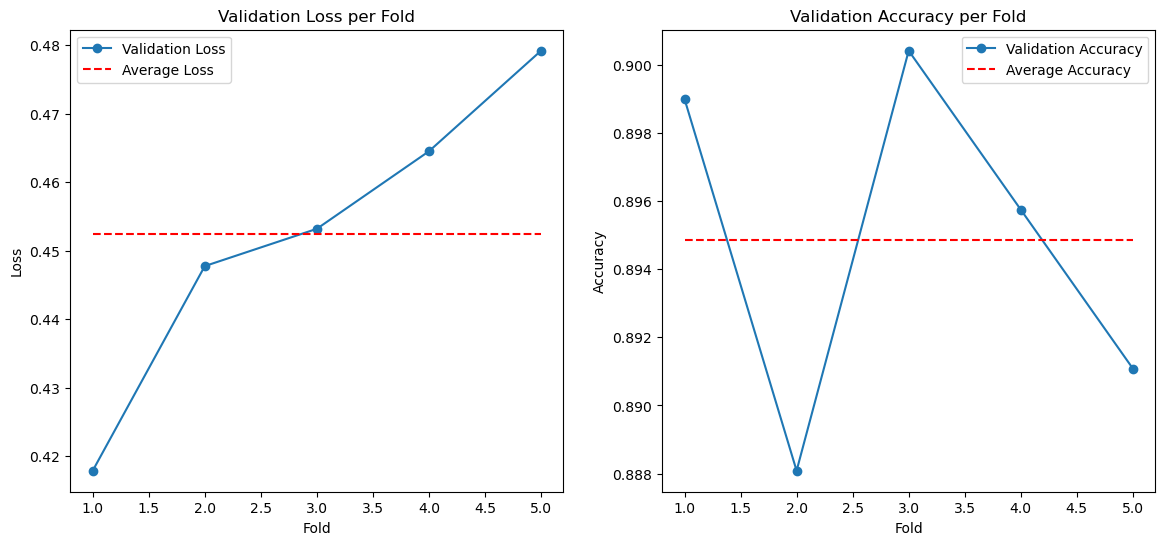

CPU times: user 12min 6s, sys: 3min 22s, total: 15min 29s
Wall time: 13min 24s


In [8]:
%%time
import numpy as np
from sklearn.model_selection import KFold
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.utils import to_categorical

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0  # Normalize data
y_train = to_categorical(y_train, 10)  # One-hot encode labels

# Define a simple model architecture function
def create_model():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Prepare for k-fold cross-validation
k = 5  # Number of folds
kf = KFold(n_splits=k, shuffle=True)

# Arrays to store scores
fold_idx = 1
scores = []

for train_index, val_index in kf.split(x_train):
    # Split data
    x_train_fold, x_val_fold = x_train[train_index], x_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]
    
    # create a model
    model_kfold_cv = create_model()
    
    # Train model
    history_kfold_cv = model_kfold_cv.fit(x_train_fold, y_train_fold, epochs=10, validation_data=(x_val_fold, y_val_fold), verbose=1)
    
    # Append the last score from the history
    scores.append((history_kfold_cv.history['val_loss'][-1], history_kfold_cv.history['val_accuracy'][-1]))

# Calculate and print average performance across all folds
average_loss, average_accuracy = np.mean(scores, axis=0)
print(f'\nK-Fold Validation Results:\nAverage Loss: {average_loss}, Average Accuracy: {average_accuracy}')

# Plotting
folds = range(1, k + 1)
val_losses, val_accuracies = zip(*scores)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(folds, val_losses, 'o-', label='Validation Loss')
plt.plot(folds, [average_loss] * k, 'r--', label='Average Loss')
plt.title('Validation Loss per Fold')
plt.xlabel('Fold')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(folds, val_accuracies, 'o-', label='Validation Accuracy')
plt.plot(folds, [average_accuracy] * k, 'r--', label='Average Accuracy')
plt.title('Validation Accuracy per Fold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

This code performs the following steps:
1. Normalizes the data and one-hot encodes the labels.
2. Defines a simple neural network model inside a function so that a fresh model can be created for each fold.
3. Uses `KFold` from `sklearn.model_selection` to generate train/validation splits.
4. Trains a new model instance on each train fold and evaluates it on the corresponding validation fold.
5. Calculates and prints the average loss and accuracy across all folds at the end.

Remember, k-fold cross-validation can be computationally expensive since it involves training and evaluating k separate models. Adjust the number of epochs, model complexity, or the dataset size as necessary to manage the computational load.